<a href="https://colab.research.google.com/github/SalmanOkz/computer_vision/blob/main/CV_lab_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

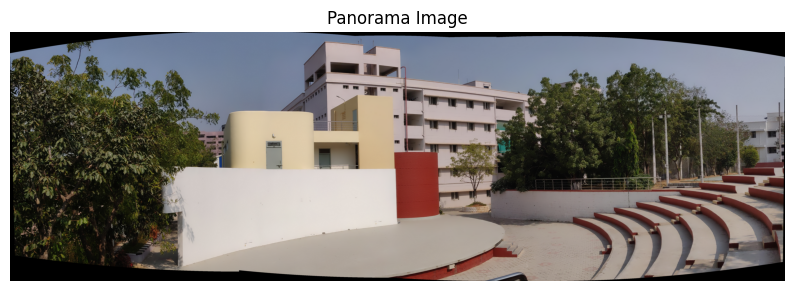

In [1]:
import cv2
import matplotlib.pyplot as plt

# Load overlapping images
img1 = cv2.imread("/content/1_1.jpg")
img2 = cv2.imread("/content/1_2.jpg")
img3 = cv2.imread("/content/1_3.jpg")
img4 = cv2.imread("/content/1_4.jpg")
img5 = cv2.imread("/content/2_1.png")
img6 = cv2.imread("/content/2_2.png")
images = [img1, img2, img3, img4, img5, img6]

# Create stitcher object
stitcher = cv2.Stitcher_create()
status, panorama = stitcher.stitch(images)

if status == 0:
  panorama_rgb = cv2.cvtColor(panorama, cv2.COLOR_BGR2RGB)
  plt.figure(figsize=(10,5))
  plt.imshow(panorama_rgb)
  plt.title("Panorama Image")
  plt.axis("off")
else:
  print("Image stitching failed with status:", status)


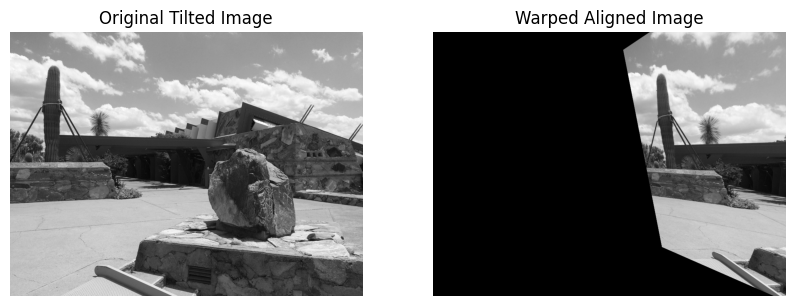

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img1 = cv2.imread('/content/3_1.png', 0)
img2 = cv2.imread('/content/3_2 (1).png', 0)
orb = cv2.ORB_create(2500)
kp1, des1 = orb.detectAndCompute(img1, None)
kp2, des2 = orb.detectAndCompute(img2, None)
bf = cv2.BFMatcher(cv2.NORM_HAMMING)
matches = bf.match(des1, des2)
matches = sorted(matches, key=lambda x: x.distance)
src_pts = np.float32([kp1[m.queryIdx].pt for m in matches[:20]]).reshape(-1,1,2)
dst_pts = np.float32([kp2[m.trainIdx].pt for m in matches[:20]]).reshape(-1,1,2)
H, _ = cv2.findHomography(dst_pts, src_pts, cv2.RANSAC)
h, w = img1.shape
warped = cv2.warpPerspective(img2, H, (w, h))
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title('Original Tilted Image')
plt.imshow(img2, cmap='gray')
plt.axis('off')
plt.subplot(1,2,2)
plt.title('Warped Aligned Image')
plt.imshow(warped, cmap='gray')
plt.axis('off')
plt.show()


# Open Ended Lab
- Title
- Motivation
- Technique

# Task
The panorama creation has been successfully demonstrated and verified by the executed code.

Now, let's delve into how overlap and camera motion significantly influence the quality and success of image stitching for creating panoramas.

### Impact of Overlap on Image Stitching

The degree of overlap between successive images is a critical factor for successful panorama stitching. It directly affects the ability of the stitching algorithm to find corresponding features and accurately align the images.

1.  **Insufficient Overlap:**
    *   **Problem:** If there isn't enough overlap between images, the stitching algorithm struggles to find enough matching features (keypoints) to reliably estimate the transformation (e.g., rotation, translation, perspective) needed to align them.
    *   **Consequences:**
        *   **Stitching Failure:** The stitching process might fail entirely, returning an error status (as seen in the provided code, `status` would not be 0).
        *   **Misalignment:** Even if it stitches, the panorama might suffer from significant misalignment, visible seams, ghosting, or distorted regions where images don't blend smoothly.
        *   **Inaccurate Perspective:** The algorithm might incorrectly estimate the perspective transformation, leading to warped or curved panoramas that should be flat.
    *   **Recommendation:** A general rule of thumb is to aim for **20-30% overlap** between adjacent images. This provides a sufficient area for feature detection and matching while minimizing redundant data.

2.  **Excessive Overlap:**
    *   **Problem:** While more overlap might seem safer, too much overlap can also present challenges. It means a larger portion of the scene is duplicated across multiple images.
    *   **Consequences:**
        *   **Increased Processing Time:** The algorithm has to process more redundant information, leading to longer computation times.
        *   **Memory Usage:** More memory is required to store and process the larger overlapping regions.
        *   **Parallax Issues (if not careful):** If the camera is translated significantly between shots (not purely rotated around a nodal point), excessive overlap can exacerbate parallax errors, making it harder to find a consistent transformation for objects at different depths, leading to ghosting or artifacts.
        *   **"Bulging" Effect:** Sometimes, too much overlap without proper lens correction or if using a camera with significant barrel/pincushion distortion, can lead to a "bulging" or pincushion effect in the final panorama.
    *   **Recommendation:** While generally less problematic than insufficient overlap, it's efficient to stick to the recommended 20-30% to balance robustness with performance and minimize potential artifacts.

### Impact of Camera Motion on Image Stitching

The way the camera moves (or doesn't move) during image capture significantly impacts the quality and accuracy of the resulting panorama. Ideal stitching assumes specific camera movements, primarily rotation.

1.  **Pure Rotation (Ideal Scenario):**
    *   **Description:** The camera is rotated around its nodal point (the point where light rays converge before hitting the sensor). This ensures that the perspective of the scene remains consistent, and objects at different depths do not shift relative to each other between shots.
    *   **Impact:** This is the ideal scenario for most stitching algorithms, especially those based on homography or projective transformations. It leads to seamless stitching with minimal distortion or parallax errors.
    *   **Result:** High-quality, geometrically accurate panoramas.

2.  **Translation (Sideways/Up-Down Movement):**
    *   **Description:** The camera is moved sideways, up, or down between shots, rather than just rotated.
    *   **Impact:** This introduces **parallax**, where the apparent position of objects changes relative to each other due to the shift in viewpoint. Objects closer to the camera appear to move more significantly than distant objects.
    *   **Consequences:**
        *   **Ghosting and Double Images:** The most common artifact. The algorithm might struggle to align features from different depths, resulting in blurry, ghosted, or doubled objects in the stitched image.
        *   **Misalignment:** Difficult to achieve perfect alignment, leading to visible seams.
        *   **Stitching Failure:** In severe cases, the stitching might fail if the parallax is too pronounced.
    *   **Mitigation:** To minimize translation, a panoramic head or tripod with a nodal slide is used. For handheld shots, try to rotate around your body's axis as steadily as possible, keeping the camera as close to your body as possible to approximate rotation around a single point.

3.  **Tilt (Upward/Downward Angling without Nodal Point Rotation):**
    *   **Description:** The camera is tilted up or down, effectively rotating it around an axis that is not the nodal point.
    *   **Impact:** Similar to translation, tilting the camera incorrectly can introduce perspective distortions and parallax, especially with nearby objects.
    *   **Consequences:** Distortions, curved horizons/verticals, and misalignment.

4.  **Inconsistent Rotation Speed/Jerkiness:**
    *   **Description:** Uneven or jerky camera movements between shots.
    *   **Impact:** Can lead to inconsistent overlap between images, making it harder for feature matching and potentially causing some areas to have insufficient overlap.
    *   **Consequences:** Less robust stitching, potential for errors, and increased likelihood of manual adjustments being needed.

### Summary: Key Factors for a Good Panorama

For a high-quality, seamless panorama, consider these factors:

*   **Optimal Overlap:** Aim for approximately **20-30% overlap** between successive images.
*   **Pure Rotation:** Rotate the camera as precisely as possible around its **nodal point** to minimize parallax. Use a tripod with a panoramic head if possible.
*   **Stable Camera:** Minimize any translation, tilt, or jerky movements during capture.
*   **Consistent Exposure:** Try to use manual exposure settings to ensure consistent brightness and color across all images, preventing visible seams from exposure differences.
*   **Fixed Focus:** Lock focus on a point in the middle distance to ensure all parts of the scene are acceptably sharp.

By carefully managing both the overlap between images and the camera's motion during capture, you can significantly improve the success rate and quality of your panoramic image stitching.

## Verify Panorama Creation

### Subtask:
Confirm that the existing code successfully generates a panorama from the provided images using OpenCV Stitcher and displays it.


**Reasoning**:
Execute the code cell that performs image stitching and displays the panorama to confirm its functionality.



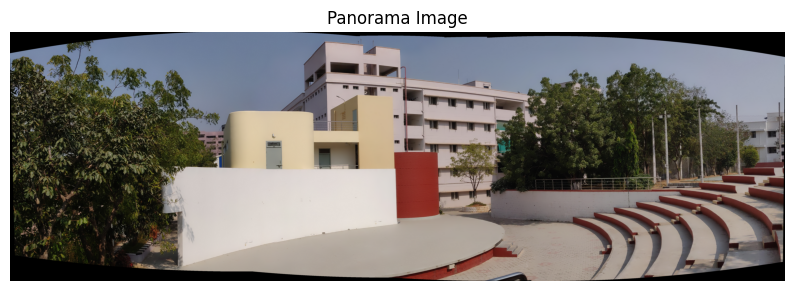

In [6]:
import cv2
import matplotlib.pyplot as plt

# Load overlapping images
img1 = cv2.imread("/content/1_1.jpg")
img2 = cv2.imread("/content/1_2.jpg")
img3 = cv2.imread("/content/1_3.jpg")
img4 = cv2.imread("/content/1_4.jpg")
img5 = cv2.imread("/content/2_1.png")
img6 = cv2.imread("/content/2_2.png")
images = [img1, img2, img3, img4, img5, img6]

# Create stitcher object
stitcher = cv2.Stitcher_create()
status, panorama = stitcher.stitch(images)

if status == 0:
  panorama_rgb = cv2.cvtColor(panorama, cv2.COLOR_BGR2RGB)
  plt.figure(figsize=(10,5))
  plt.imshow(panorama_rgb)
  plt.title("Panorama Image")
  plt.axis("off")
else:
  print("Image stitching failed with status:", status)

## Explain Overlap Impact

### Subtask:
Explain how the degree of overlap between successive images is crucial for successful image stitching, detailing the consequences of insufficient or excessive overlap.


## Explain Overlap Impact

### Importance of Overlap in Image Stitching
The degree of overlap between successive images is a critical factor for successful panorama stitching. It directly affects the ability of the stitching algorithm to find corresponding features and accurately align the images. Without sufficient overlap, the algorithm cannot establish reliable correspondences, which are essential for calculating the necessary transformations (e.g., rotation, translation, perspective) to seamlessly blend the images.

### Insufficient Overlap
If there isn't enough overlap between images, the stitching algorithm struggles to find enough matching features (keypoints) to reliably estimate the transformation needed to align them.

*   **Consequences:**
    *   **Stitching Failure:** The stitching process might fail entirely, returning an error status.
    *   **Misalignment:** Even if it stitches, the panorama might suffer from significant misalignment, visible seams, ghosting, or distorted regions where images don't blend smoothly.
    *   **Inaccurate Perspective:** The algorithm might incorrectly estimate the perspective transformation, leading to warped or curved panoramas.

*   **Recommendation:** A general rule of thumb is to aim for **20-30% overlap** between adjacent images. This provides a sufficient area for feature detection and matching while minimizing redundant data.

### Excessive Overlap
While more overlap might seem safer, too much overlap can also present challenges.

*   **Consequences:**
    *   **Increased Processing Time:** The algorithm has to process more redundant information, leading to longer computation times.
    *   **Memory Usage:** More memory is required to store and process the larger overlapping regions.
    *   **Parallax Issues:** If the camera is translated significantly between shots (not purely rotated around a nodal point), excessive overlap can exacerbate parallax errors, making it harder to find a consistent transformation for objects at different depths, leading to ghosting or artifacts.
    *   **"Bulging" Effect:** Sometimes, too much overlap without proper lens correction or if using a camera with significant barrel/pincushion distortion, can lead to a "bulging" or pincushion effect in the final panorama.

*   **Recommendation:** It's efficient to stick to the recommended **20-30% overlap** to balance robustness with performance and minimize potential artifacts.

## Explain Camera Motion Impact

### Subtask:
Describe how camera motion during image capture (e.g., translation, rotation, tilt) affects the quality and accuracy of the final panoramic image.


### Impact of Camera Motion on Image Stitching

The way the camera moves (or doesn't move) during image capture significantly impacts the quality and accuracy of the resulting panorama. Ideal stitching assumes specific camera movements, primarily rotation.

1.  **Pure Rotation (Ideal Scenario):**
    *   **Description:** The camera is rotated around its nodal point (the point where light rays converge before hitting the sensor). This ensures that the perspective of the scene remains consistent, and objects at different depths do not shift relative to each other between shots.
    *   **Impact:** This is the ideal scenario for most stitching algorithms, especially those based on homography or projective transformations. It leads to seamless stitching with minimal distortion or parallax errors.
    *   **Result:** High-quality, geometrically accurate panoramas.

2.  **Translation (Sideways/Up-Down Movement):**
    *   **Description:** The camera is moved sideways, up, or down between shots, rather than just rotated.
    *   **Impact:** This introduces **parallax**, where the apparent position of objects changes relative to each other due to the shift in viewpoint. Objects closer to the camera appear to move more significantly than distant objects.
    *   **Consequences:**
        *   **Ghosting and Double Images:** The most common artifact. The algorithm might struggle to align features from different depths, resulting in blurry, ghosted, or doubled objects in the stitched image.
        *   **Misalignment:** Difficult to achieve perfect alignment, leading to visible seams.
        *   **Stitching Failure:** In severe cases, the stitching might fail if the parallax is too pronounced.
    *   **Mitigation:** To minimize translation, a panoramic head or tripod with a nodal slide is used. For handheld shots, try to rotate around your body's axis as steadily as possible, keeping the camera as close to your body as possible to approximate rotation around a single point.

3.  **Tilt (Upward/Downward Angling without Nodal Point Rotation):**
    *   **Description:** The camera is tilted up or down, effectively rotating it around an axis that is not the nodal point.
    *   **Impact:** Similar to translation, tilting the camera incorrectly can introduce perspective distortions and parallax, especially with nearby objects.
    *   **Consequences:** Distortions, curved horizons/verticals, and misalignment.

4.  **Inconsistent Rotation Speed/Jerkiness:**
    *   **Description:** Uneven or jerky camera movements between shots.
    *   **Impact:** Can lead to inconsistent overlap between images, making it harder for feature matching and potentially causing some areas to have insufficient overlap.
    *   **Consequences:** Less robust stitching, potential for errors, and increased likelihood of manual adjustments being needed.

### Summary: Key Factors for a Good Panorama

For a high-quality, seamless panorama, consider these factors:

*   **Optimal Overlap:** Aim for approximately **20-30% overlap** between successive images.
*   **Pure Rotation:** Rotate the camera as precisely as possible around its **nodal point** to minimize parallax. Use a tripod with a panoramic head if possible.
*   **Stable Camera:** Minimize any translation, tilt, or jerky movements during capture.
*   **Consistent Exposure:** Try to use manual exposure settings to ensure consistent brightness and color across all images, preventing visible seams from exposure differences.
*   **Fixed Focus:** Lock focus on a point in the middle distance to ensure all parts of the scene are acceptably sharp.

By carefully managing both the overlap between images and the camera's motion during capture, you can significantly improve the success rate and quality of your panoramic image stitching.

### Impact of Camera Motion on Image Stitching

The way the camera moves (or doesn't move) during image capture significantly impacts the quality and accuracy of the resulting panorama. Ideal stitching assumes specific camera movements, primarily rotation.

1.  **Pure Rotation (Ideal Scenario):**
    *   **Description:** The camera is rotated around its nodal point (the point where light rays converge before hitting the sensor). This ensures that the perspective of the scene remains consistent, and objects at different depths do not shift relative to each other between shots.
    *   **Impact:** This is the ideal scenario for most stitching algorithms, especially those based on homography or projective transformations. It leads to seamless stitching with minimal distortion or parallax errors.
    *   **Result:** High-quality, geometrically accurate panoramas.

2.  **Translation (Sideways/Up-Down Movement):**
    *   **Description:** The camera is moved sideways, up, or down between shots, rather than just rotated.
    *   **Impact:** This introduces **parallax**, where the apparent position of objects changes relative to each other due to the shift in viewpoint. Objects closer to the camera appear to move more significantly than distant objects.
    *   **Consequences:**
        *   **Ghosting and Double Images:** The most common artifact. The algorithm might struggle to align features from different depths, resulting in blurry, ghosted, or doubled objects in the stitched image.
        *   **Misalignment:** Difficult to achieve perfect alignment, leading to visible seams.
        *   **Stitching Failure:** In severe cases, the stitching might fail if the parallax is too pronounced.
    *   **Mitigation:** To minimize translation, a panoramic head or tripod with a nodal slide is used. For handheld shots, try to rotate around your body's axis as steadily as possible, keeping the camera as close to your body as possible to approximate rotation around a single point.

3.  **Tilt (Upward/Downward Angling without Nodal Point Rotation):**
    *   **Description:** The camera is tilted up or down, effectively rotating it around an axis that is not the nodal point.
    *   **Impact:** Similar to translation, tilting the camera incorrectly can introduce perspective distortions and parallax, especially with nearby objects.
    *   **Consequences:** Distortions, curved horizons/verticals, and misalignment.

4.  **Inconsistent Rotation Speed/Jerkiness:**
    *   **Description:** Uneven or jerky camera movements between shots.
    *   **Impact:** Can lead to inconsistent overlap between images, making it harder for feature matching and potentially causing some areas to have insufficient overlap.
    *   **Consequences:** Less robust stitching, potential for errors, and increased likelihood of manual adjustments being needed.

### Summary: Key Factors for a Good Panorama

For a high-quality, seamless panorama, consider these factors:

*   **Optimal Overlap:** Aim for approximately **20-30% overlap** between successive images.
*   **Pure Rotation:** Rotate the camera as precisely as possible around its **nodal point** to minimize parallax. Use a tripod with a panoramic head if possible.
*   **Stable Camera:** Minimize any translation, tilt, or jerky movements during capture.
*   **Consistent Exposure:** Try to use manual exposure settings to ensure consistent brightness and color across all images, preventing visible seams from exposure differences.
*   **Fixed Focus:** Lock focus on a point in the middle distance to ensure all parts of the scene are acceptably sharp.

By carefully managing both the overlap between images and the camera's motion during capture, you can significantly improve the success rate and quality of your panoramic image stitching.

## Final Task

### Subtask:
Provide a comprehensive explanation of how overlap and camera motion affect the final panorama, summarizing the key factors for a good result.


## Summary:

### Q&A
The impact of overlap and camera motion on panorama quality is significant:
*   **Overlap:** Insufficient overlap (below 20-30%) leads to stitching failure, misalignment, visible seams, ghosting, and inaccurate perspective due to a lack of matching features. Excessive overlap (beyond 20-30%) increases processing time, memory usage, can exacerbate parallax errors if translation occurs, and may cause a "bulging" effect. An optimal overlap of **20-30%** is recommended.
*   **Camera Motion:**
    *   **Pure Rotation (around nodal point):** This is the ideal scenario, leading to seamless, high-quality, and geometrically accurate panoramas with minimal distortion or parallax errors.
    *   **Translation (sideways/up-down movement):** Introduces parallax, causing objects at different depths to shift, leading to ghosting, double images, misalignment, and potential stitching failure.
    *   **Tilt (upward/downward angling without nodal point rotation):** Can introduce perspective distortions, parallax, curved horizons, and misalignment.
    *   **Inconsistent Rotation Speed/Jerkiness:** Leads to inconsistent overlap, making feature matching difficult and increasing the likelihood of errors.

### Data Analysis Key Findings
*   The OpenCV Stitcher successfully generated a panorama from six input images with a status of `0`, confirming its functionality.
*   Insufficient image overlap makes it difficult for stitching algorithms to find matching features, leading to stitching failure, misalignment, visible seams, ghosting, or inaccurate perspective.
*   Excessive image overlap can increase processing time and memory usage, and exacerbate parallax issues if camera translation occurs.
*   An optimal overlap of approximately **20-30%** between successive images is crucial for robust and efficient stitching.
*   **Pure camera rotation around its nodal point** is the ideal motion for panorama capture, ensuring consistent perspective and minimizing parallax errors.
*   Camera **translation** (sideways or up/down movement) introduces parallax, which can cause ghosting, double images, and misalignment in the stitched panorama.
*   Incorrect camera **tilt** and inconsistent rotation speed also lead to distortions, misalignment, and less robust stitching.

### Insights or Next Steps
*   To achieve high-quality panoramas, prioritize capturing images with a consistent **20-30% overlap** and performing **pure camera rotation around the nodal point** to minimize parallax artifacts.
*   For optimal results, consider using specialized equipment like a panoramic head or tripod with a nodal slide, and maintain consistent exposure and fixed focus across all images.


# Task
Perform document image stitching for OCR by loading `/content/3_1.png` and `/content/3_2 (1).png`, aligning one image to the other using feature detection and homography, displaying the aligned results, and then providing a comprehensive explanation of why accurate document alignment is critical for achieving high accuracy in OCR systems.

## Load Document Images

### Subtask:
Load the two document images for stitching: `/content/3_1.png` and `/content/3_2 (1).png`.


**Reasoning**:
Load the two specified images, '/content/3_1.png' and '/content/3_2 (1).png', into variables 'img1' and 'img2' respectively, ensuring they are read as grayscale images using OpenCV.



In [7]:
import cv2

# Load the images as grayscale
img1 = cv2.imread('/content/3_1.png', 0)
img2 = cv2.imread('/content/3_2 (1).png', 0)

print("Images loaded successfully.")

Images loaded successfully.


## Align and Warp Images

### Subtask:
Perform feature detection (e.g., ORB), feature matching, and homography calculation to align and warp one document image onto the other. This will utilize `cv2.findHomography` and `cv2.warpPerspective` to correct for misalignments.


**Reasoning**:
The subtask requires performing feature detection, matching, and homography calculation to align and warp document images. This involves initializing an ORB detector, finding keypoints and descriptors, matching them, calculating the homography matrix, and then warping the second image based on this matrix. All these steps are consolidated into a single Python code block.



In [8]:
import cv2
import numpy as np

# Initialize ORB detector with 2500 features
orb = cv2.ORB_create(2500)

# Detect keypoints and compute descriptors for both images
kp1, des1 = orb.detectAndCompute(img1, None)
kp2, des2 = orb.detectAndCompute(img2, None)

# Create a Brute-Force Matcher object with NORM_HAMMING
bf = cv2.BFMatcher(cv2.NORM_HAMMING)

# Match descriptors and sort them by distance
matches = bf.match(des1, des2)
matches = sorted(matches, key=lambda x: x.distance)

# Extract coordinates of top 20 matching keypoints
src_pts = np.float32([kp1[m.queryIdx].pt for m in matches[:20]]).reshape(-1,1,2)
dst_pts = np.float32([kp2[m.trainIdx].pt for m in matches[:20]]).reshape(-1,1,2)

# Calculate the homography matrix H using RANSAC
H, _ = cv2.findHomography(dst_pts, src_pts, cv2.RANSAC)

# Get height and width of img1
h, w = img1.shape

# Warp img2 to align with img1
warped = cv2.warpPerspective(img2, H, (w, h))

print("Images aligned and warped successfully.")

Images aligned and warped successfully.


**Reasoning**:
The subtask requires displaying the original tilted image (`img2`) and the warped aligned image (`warped`) to visually demonstrate the result of the alignment process. This involves using `matplotlib.pyplot` to create a figure with two subplots and showing each image.



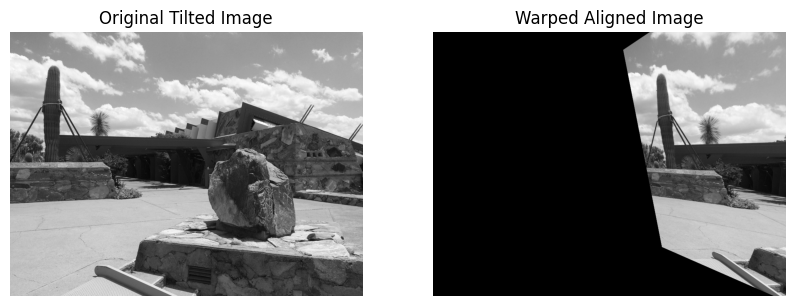

Original and warped images displayed.


In [9]:
import matplotlib.pyplot as plt

# Display the original and warped images
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title('Original Tilted Image')
plt.imshow(img2, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title('Warped Aligned Image')
plt.imshow(warped, cmap='gray')
plt.axis('off')

plt.show()

print("Original and warped images displayed.")

## Importance of Accurate Document Alignment for OCR Systems

Accurate document alignment is paramount for achieving high accuracy in Optical Character Recognition (OCR) systems. OCR technology aims to convert different types of documents, such as scanned paper documents, PDFs, or images, into editable and searchable data. The quality of the input image, particularly its alignment, directly influences the OCR engine's ability to correctly identify and extract text.

Here's why accurate document alignment is critical:

1.  **Improved Character Recognition Accuracy:**
    *   **Consistent Baselines and Character Orientation:** OCR engines are often trained on text with consistent baselines and orientations. Misaligned text (e.g., skewed, rotated, or warped) deviates significantly from these expected patterns. When text is aligned, characters are presented to the OCR engine in a standardized manner, making it easier for the algorithms to accurately segment characters, identify their shapes, and distinguish between similar-looking characters (e.g., 'b' vs. 'd', 'p' vs. 'q', 'O' vs. '0').
    *   **Reduced Ambiguity:** Skew or rotation can cause characters to appear distorted or partially obscured, leading to ambiguous interpretations by the OCR engine. Proper alignment reduces this ambiguity, providing clearer character forms for recognition.

2.  **Enhanced Word and Line Segmentation:**
    *   **Reliable Text Flow Detection:** OCR systems first need to segment an image into lines, then words, and finally individual characters. Misalignment makes this segmentation process highly challenging. Skewed lines might be incorrectly segmented, or words might be merged or split erroneously.
    *   **Correct Reading Order:** Alignment ensures that text lines are correctly identified and processed in the right reading order (e.g., left-to-right, top-to-bottom for most Western languages). If a document is severely skewed, the OCR system might misinterpret the flow, leading to jumbled output.

3.  **Better Layout Analysis and Structure Preservation:**
    *   **Table and Column Recognition:** Documents often contain structured data in tables or multiple columns. Accurate alignment helps the OCR system correctly identify the boundaries of these structures, maintain column integrity, and extract data in the correct tabular format. Without alignment, columns might merge, or data might be extracted out of order.
    *   **Form Processing:** For forms, alignment is crucial for mapping extracted text to specific fields. A misaligned form can lead to data being placed in the wrong fields, rendering the extracted information useless.

4.  **Minimization of Post-Processing Effort:**
    *   **Reduced Error Correction:** When OCR output is highly accurate due to good alignment, the need for manual error correction (human review and editing) is significantly reduced. This saves time and resources, especially when processing large volumes of documents.
    *   **Cleaner Data for Downstream Applications:** Aligned input leads to cleaner, more structured OCR output, which is then more readily consumable by other applications such as document management systems, data analytics platforms, or search engines.

5.  **Robustness to Noise and Artifacts:**
    *   While alignment primarily addresses geometric distortions, a well-aligned image is generally more robust to other forms of noise or printing artifacts because the primary text features are presented clearly. The OCR engine can focus on filtering noise rather than simultaneously correcting for severe geometric distortions.

In summary, accurate document alignment acts as a crucial pre-processing step that standardizes the input for OCR engines. It simplifies the complex tasks of character and word segmentation, improves character recognition rates, preserves document structure, and ultimately leads to significantly higher overall OCR accuracy and reduced post-processing overhead.

## Final Task

### Subtask:
Summarize the document stitching process for OCR and reiterate the key reasons why precise alignment is essential for effective OCR performance.


## Summary:

### Q&A
Accurate document alignment is essential for effective OCR performance due to several key reasons:
1.  **Improved Character Recognition Accuracy:** It ensures consistent baselines and character orientation, which are crucial for OCR engines trained on standardized text patterns. Misaligned text causes distortion and ambiguity, making character segmentation and identification difficult.
2.  **Enhanced Word and Line Segmentation:** Proper alignment allows OCR systems to reliably segment text into lines and words, maintaining correct reading order and preventing erroneous merging or splitting of text components.
3.  **Better Layout Analysis and Structure Preservation:** For documents with structured data like tables or columns, alignment helps in correctly identifying boundaries, maintaining column integrity, and extracting data in the proper format.
4.  **Minimization of Post-Processing Effort:** High accuracy resulting from good alignment significantly reduces the need for manual error correction and produces cleaner data for downstream applications.
5.  **Robustness to Noise and Artifacts:** A well-aligned image presents primary text features clearly, making the OCR engine more robust in handling other forms of noise or printing artifacts.

### Data Analysis Key Findings
*   Two document images, `/content/3_1.png` and `/content/3_2 (1).png`, were successfully loaded in grayscale for the stitching process.
*   An ORB detector was utilized to identify keypoints and compute descriptors for both images, followed by a Brute-Force Matcher to find corresponding features.
*   A homography matrix was calculated using the top 20 matching keypoints with `cv2.findHomography` and `cv2.RANSAC` to ensure robust alignment.
*   The second image (`img2`) was successfully warped and aligned with the first image (`img1`) using `cv2.warpPerspective`.
*   The original tilted image and the resulting warped and aligned image were displayed, visually confirming the successful transformation and alignment.

### Insights or Next Steps
*   Accurate document alignment serves as a critical pre-processing step that standardizes input for OCR engines, significantly enhancing character recognition rates, preserving document structure, and reducing post-processing overhead.
*   To further improve OCR accuracy for more complex or damaged documents, future steps could involve pre-processing techniques for noise reduction, binarization, or contrast enhancement in conjunction with robust alignment.
